<a href="https://colab.research.google.com/github/adityatandel86-design/my-python-project/blob/main/finalproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas matplotlib seaborn

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


First 5 rows:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   Na

/tmp/ipykernel_6962/913095688.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.data['Age'].fillna(self.data['Age'].mean(), inplace=True)


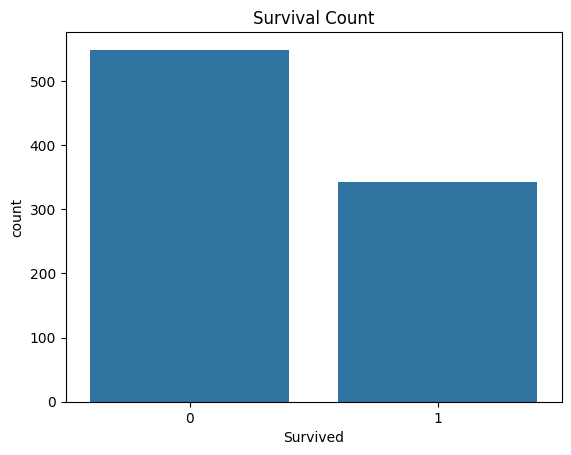

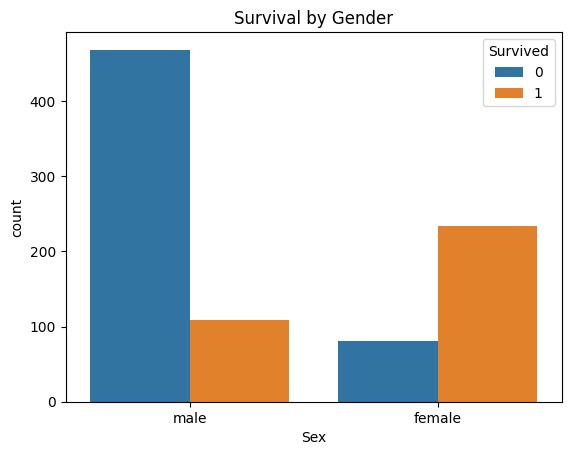

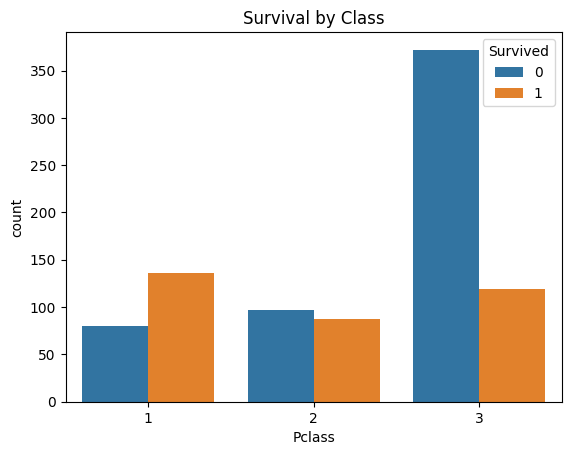

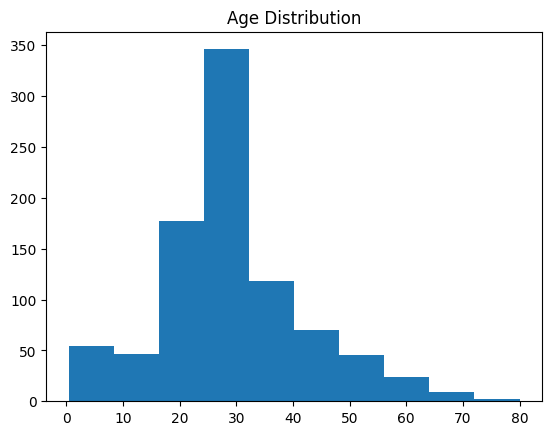

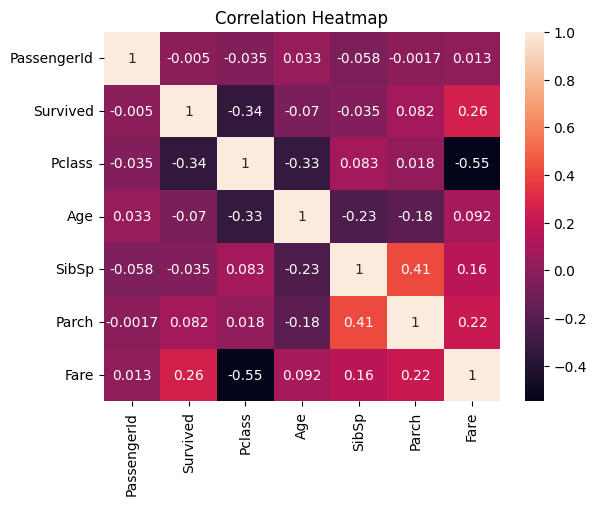

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class TitanicAnalyzer:

    def __init__(self, data):
        self.data = data

    # ---------------- EXPLORE ----------------
    def explore(self):
        print("First 5 rows:\n", self.data.head())
        print("\nInfo:\n")
        print(self.data.info())
        print("\nDescribe:\n", self.data.describe())

    # ---------------- CLEAN ----------------
    def clean_data(self):
        print("\nMissing values:\n", self.data.isnull().sum())

        # Fill Age with mean
        self.data['Age'].fillna(self.data['Age'].mean(), inplace=True)

        # Drop Cabin column (too many nulls)
        self.data.drop(columns=['Cabin'], inplace=True)

        print("✅ Data cleaned!")

    # ---------------- ANALYSIS ----------------
    def survival_analysis(self):
        print("\nSurvival Count:\n", self.data['Survived'].value_counts())

        print("\nSurvival by Gender:\n", pd.crosstab(self.data['Sex'], self.data['Survived']))

        print("\nSurvival by Class:\n", pd.crosstab(self.data['Pclass'], self.data['Survived']))

    # ---------------- VISUALIZATION ----------------
    def visualize(self):

        # Survival Count
        sns.countplot(x='Survived', data=self.data)
        plt.title("Survival Count")
        plt.show()

        # Gender vs Survival
        sns.countplot(x='Sex', hue='Survived', data=self.data)
        plt.title("Survival by Gender")
        plt.show()

        # Class vs Survival
        sns.countplot(x='Pclass', hue='Survived', data=self.data)
        plt.title("Survival by Class")
        plt.show()

        # Age Distribution
        plt.hist(self.data['Age'])
        plt.title("Age Distribution")
        plt.show()

        # Correlation Heatmap
        sns.heatmap(self.data.corr(numeric_only=True), annot=True)
        plt.title("Correlation Heatmap")
        plt.show()


# ---------------- RUN PROJECT ----------------
analyzer = TitanicAnalyzer(df)

analyzer.explore()
analyzer.clean_data()
analyzer.survival_analysis()
analyzer.visualize()